<a href="https://colab.research.google.com/github/Uday-1402/ML_Learn/blob/main/Understanding_your_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Understanding your data - Lecture 1

In [ ]:
# Asking basic questions | EDA {univariate analysis} | EDA {multivariate analysis} | Pandas Profiler Library

In [ ]:
import pandas as pd
df = pd.read_csv('/content/train.csv')

# How Big is the data?

In [ ]:
df.shape

(891, 12)

# What does data look like?

In [ ]:
df.head() # gives top 5 rows. (There may be bias.)
df.sample(5) # better : gives 5 random rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
807,808,0,3,"Pettersson, Miss. Ellen Natalia",female,18.0,0,0,347087,7.7750,NaN,S
248,249,1,1,"Beckwith, Mr. Richard Leonard",male,37.0,1,1,11751,52.5542,D35,S
787,788,0,3,"Rice, Master. George Hugh",male,8.0,4,1,382652,29.1250,NaN,Q
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
872,873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S


# What is the data type of cols?

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Are there missing values?

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# How does data look mathematically?

In [ ]:
df.describe() # Gives a high level statistical summary

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Are there duplicate values?

In [ ]:
df.duplicated().sum()

np.int64(0)

# Correlation between columns?

In [ ]:
df.select_dtypes(include='number').corr() # select_dtypes(include='number') takes only numerical columns in consideration else name column will cause problem because correlation can be there only for numerical values.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


In [ ]:
df.select_dtypes(include='number').corr()['Survived']

,Survived
PassengerId,-0.005007
Survived,1.000000
Pclass,-0.338481
Age,-0.077221
SibSp,-0.035322
Parch,0.081629
Fare,0.257307


# EDA {Univariate Analysis : Analysis of a single variable/Analysis of a single Column.}

# Types of data :-
1. Numerical
2. Categorical

In [ ]:
import pandas as pd
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Categorical Data

(Name, Sex, SibSp, Parch, Ticket, Cabin, Embarked)

a. Countplot

<Axes: xlabel='Survived', ylabel='count'>

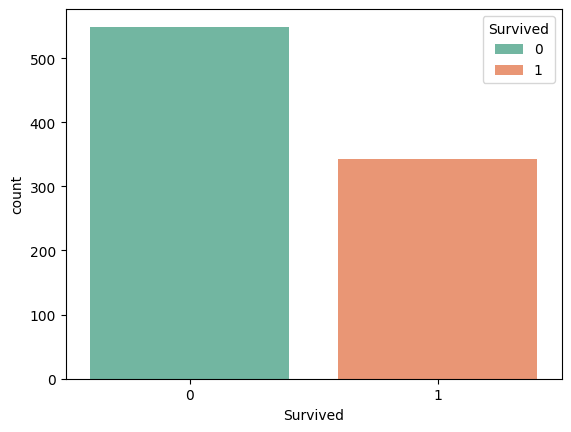

In [ ]:
sns.countplot(x='Survived',data=df,hue='Survived', palette='Set2')
# df['Survived'].value_counts().plot(kind='bar')

<Axes: xlabel='Pclass', ylabel='count'>

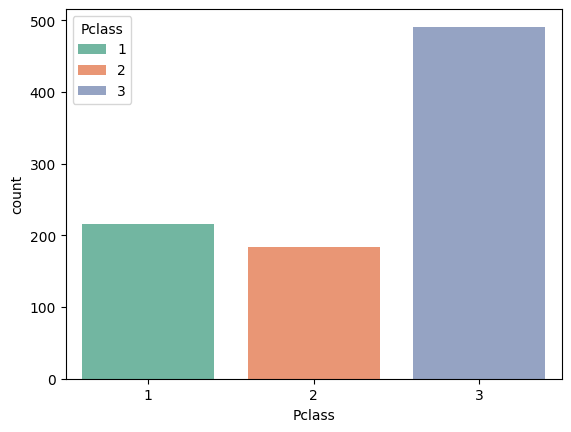

In [ ]:
sns.countplot(x=df['Pclass'],hue=df['Pclass'],palette='Set2')


<Axes: xlabel='Sex', ylabel='count'>

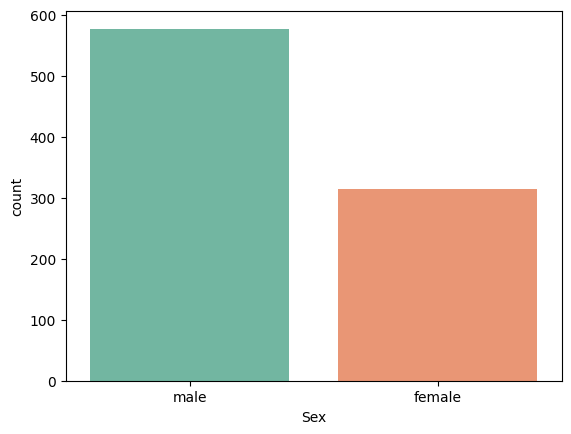

In [ ]:
sns.countplot(x=df['Sex'],hue=df['Sex'],palette='Set2')


<Axes: xlabel='Embarked', ylabel='count'>

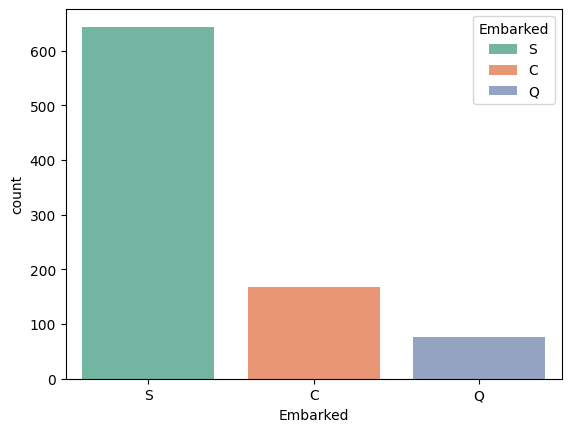

In [ ]:
sns.countplot(x=df['Embarked'],hue=df['Embarked'],palette='Set2')


b. PieChart

<Axes: ylabel='count'>

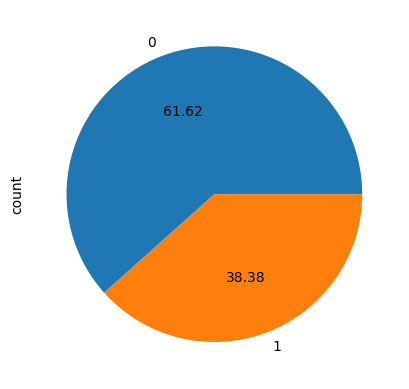

In [ ]:
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

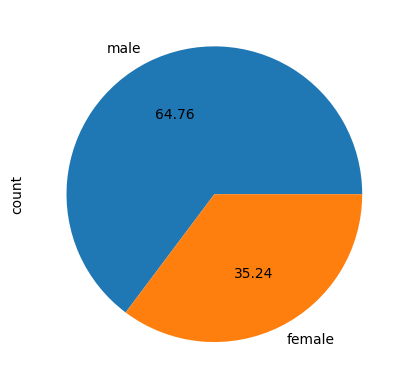

In [ ]:
df['Sex'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

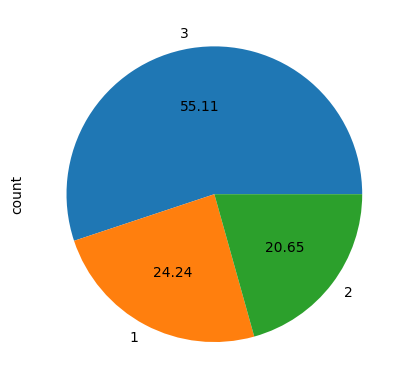

In [ ]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f')

# 2. Numerical Data

a. Histogram

(array([100., 346., 188.,  69.,  11.]),
 array([ 0.42 , 16.336, 32.252, 48.168, 64.084, 80.   ]),
 <BarContainer object of 5 artists>)

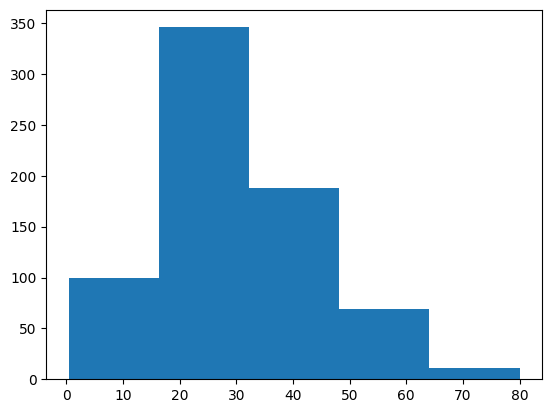

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['Age'],bins=5)
# Gives the range. (No. of items in that range. Here no. of people in different age ranges.)

b. Distplot

/tmp/ipykernel_173/970433550.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

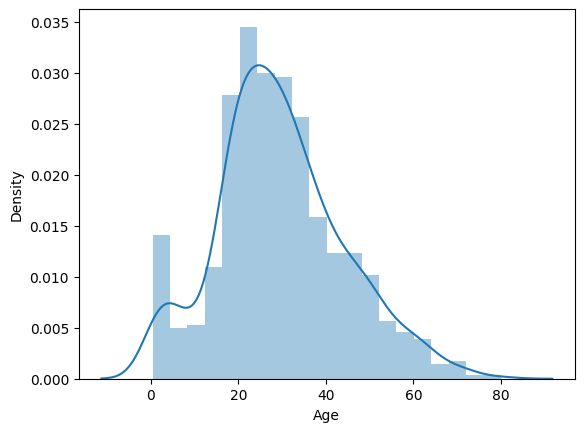

In [ ]:
sns.distplot(df['Age'])
# Gives probability density function.
# Tells about skewness in data.(peak towards left or right not at the center.)

c. Boxplot

In [ ]:
# Gives a 5 number summary.
# IQR = Interquartile Range = Q1 -> Q3
# Q1 = 25th percentile, Q3 = 75th percentile.
# Outliers : Minimum = Q1 - 1.5*IQR, Maximum = Q3 + 1.5*IQR

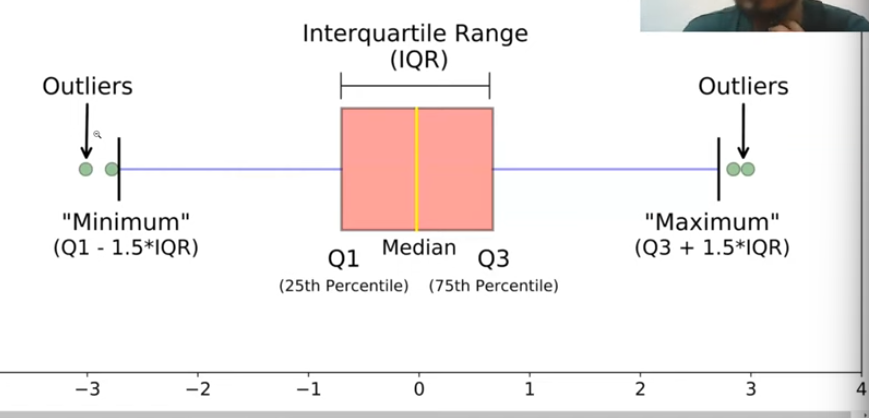

<Axes: xlabel='Fare'>

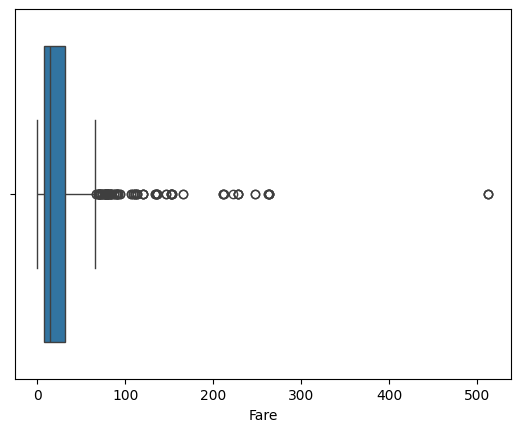

In [ ]:
sns.boxplot(x=df['Fare'])

In [ ]:
# Shifted towards left, 500 is an outlier should not depend on that.
# Boxplot helps identify noise in data/outliers in data.

<Axes: xlabel='Age'>

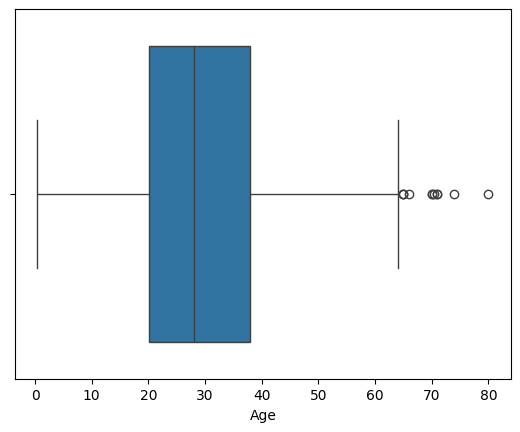

In [ ]:
sns.boxplot(x=df['Age'])

In [ ]:
df['Age'].min()

0.42

In [ ]:
df['Age'].max()

80.0

In [ ]:
df['Age'].mean()

np.float64(29.69911764705882)

In [ ]:
# Skewness
# Positive => Towards Right
# Negative => Towards left
df['Age'].skew()

np.float64(0.38910778230082704)

# EDA {Bivariate and Multivariate analysis : Analysis on two and more than two columns}

In [1]:
import pandas as pd
import seaborn as sns

In [4]:
tips = sns.load_dataset('tips')

In [5]:
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [7]:
titanic = pd.read_csv('train.csv')

In [8]:
flights = sns.load_dataset('flights')

In [10]:
flights.sample(5)

,year,month,passengers
136,1960,May,472
141,1960,Oct,461
64,1954,May,234
65,1954,Jun,264
114,1958,Jul,491


In [11]:
iris = sns.load_dataset('iris')

In [12]:
iris.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
78,6.0,2.9,4.5,1.5,versicolor
41,4.5,2.3,1.3,0.3,setosa
103,6.3,2.9,5.6,1.8,virginica
75,6.6,3.0,4.4,1.4,versicolor
30,4.8,3.1,1.6,0.2,setosa
128,6.4,2.8,5.6,2.1,virginica
34,4.9,3.1,1.5,0.2,setosa
142,5.8,2.7,5.1,1.9,virginica
10,5.4,3.7,1.5,0.2,setosa
67,5.8,2.7,4.1,1.0,versicolor


# 1. Scatterplot (Numerical - Numerical)

<Axes: xlabel='total_bill', ylabel='tip'>

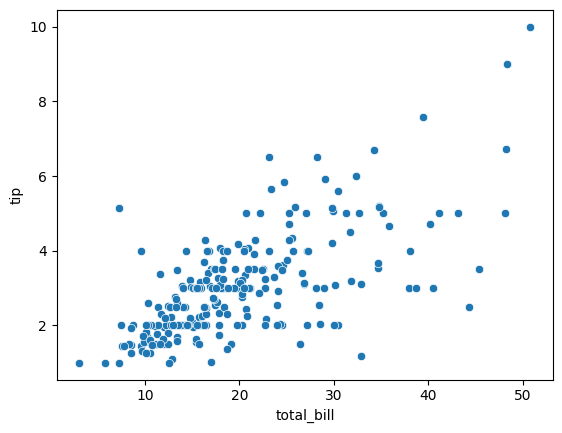

In [16]:
#Bivariate
sns.scatterplot(x=tips['total_bill'],y=tips['tip'])

<Axes: xlabel='total_bill', ylabel='tip'>

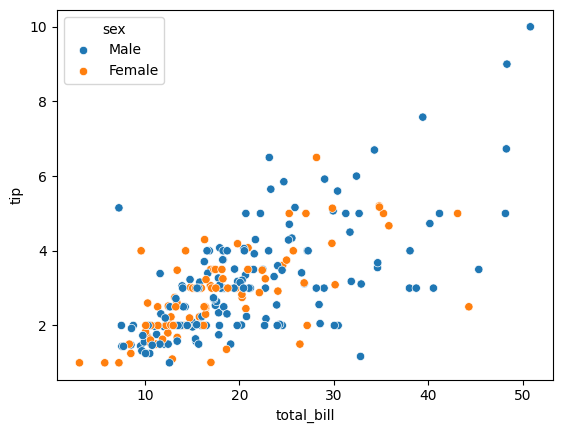

In [17]:
# Multivariate
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'])

<Axes: xlabel='total_bill', ylabel='tip'>

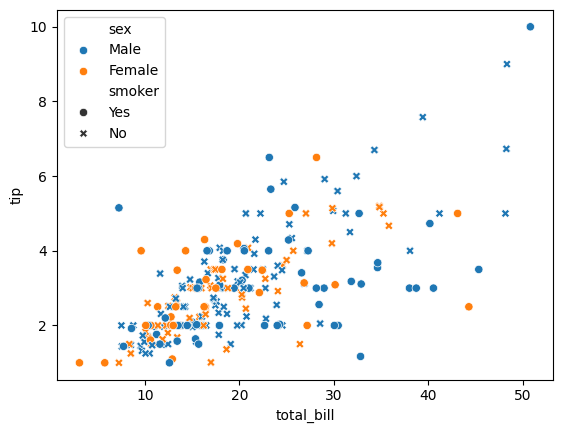

In [18]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'],style=tips['smoker'])

<Axes: xlabel='total_bill', ylabel='tip'>

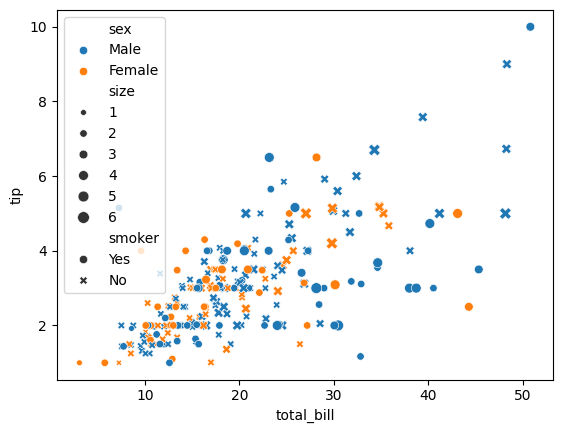

In [19]:
sns.scatterplot(x=tips['total_bill'],y=tips['tip'],hue=tips['sex'],style=tips['smoker'],size=tips['size'])

# 2. Bar Plot (Numerical - Categorical)

<Axes: xlabel='Pclass', ylabel='Age'>

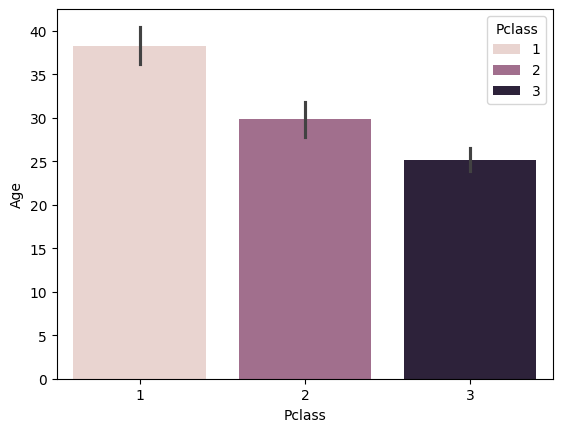

In [21]:
sns.barplot(x=titanic['Pclass'],y=titanic['Age'],hue=titanic['Pclass'])

<Axes: xlabel='Pclass', ylabel='Fare'>

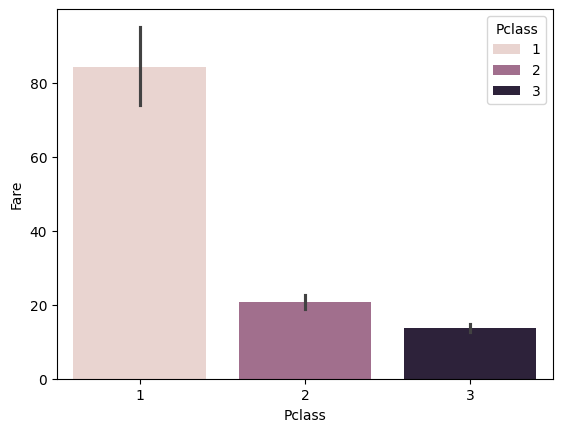

In [22]:
sns.barplot(x=titanic['Pclass'],y=titanic['Fare'],hue=titanic['Pclass'])

<Axes: xlabel='Pclass', ylabel='Fare'>

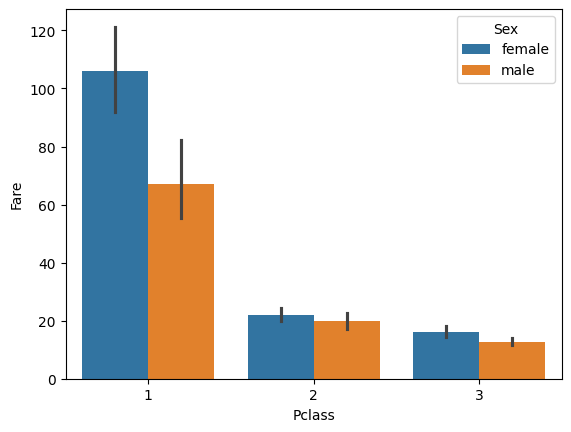

In [23]:
sns.barplot(x=titanic['Pclass'],y=titanic['Fare'],hue=titanic['Sex'])

<Axes: xlabel='Pclass', ylabel='Age'>

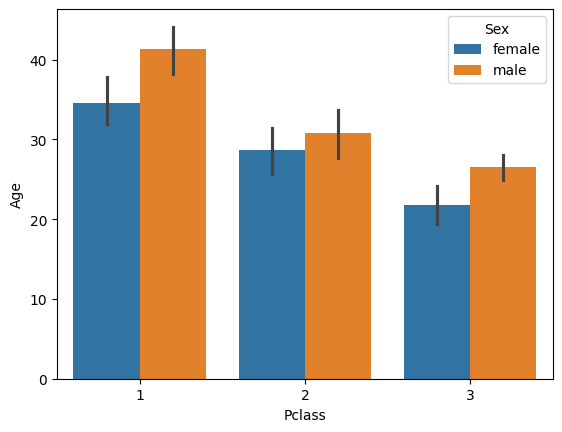

In [24]:
sns.barplot(x=titanic['Pclass'],y=titanic['Age'],hue=titanic['Sex'])

# 3. Box Plot (Numerical - Categorical)

<Axes: xlabel='Sex', ylabel='Age'>

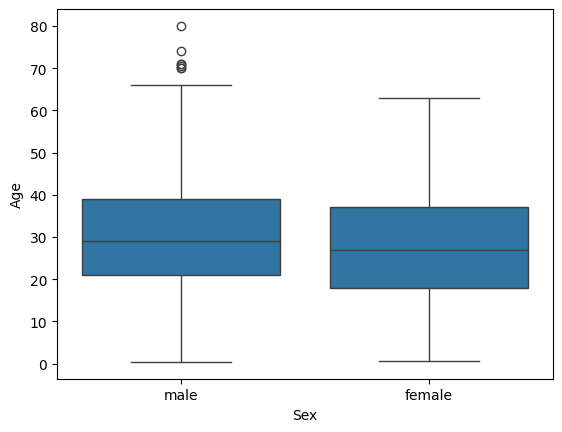

In [25]:
sns.boxplot(x=titanic['Sex'],y=titanic['Age'])
#

<Axes: xlabel='Sex', ylabel='Age'>

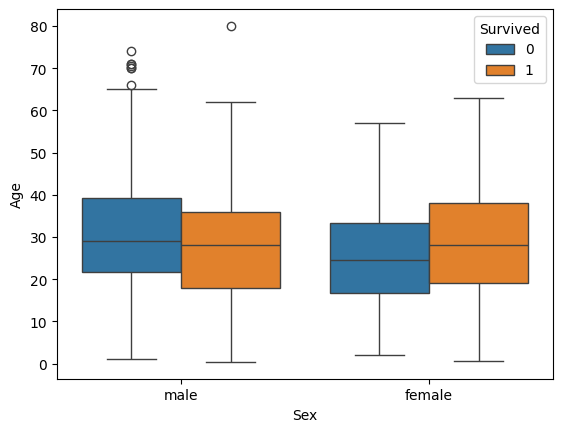

In [26]:
sns.boxplot(x=titanic['Sex'],y=titanic['Age'],hue=titanic['Survived'])

# 3. DistPlot (Numerical - Categorical)

/tmp/ipykernel_244/3830672570.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=titanic[titanic['Survived']==0]['Age'],hist = False)
/tmp/ipykernel_244/3830672570.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=titanic[titanic['Survived']==1]['Age'],hist = False)


<Axes: ylabel='Density'>

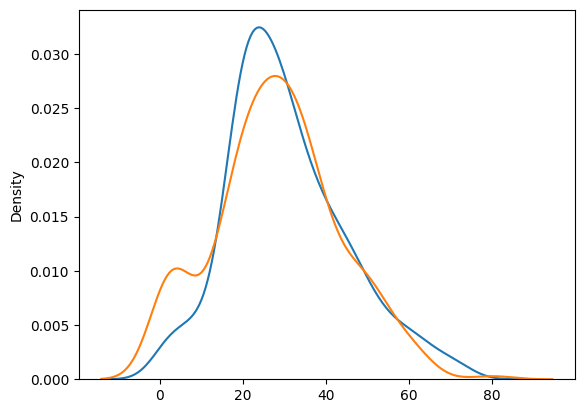

In [31]:
sns.distplot(x=titanic[titanic['Survived']==0]['Age'],hist = False)
sns.distplot(x=titanic[titanic['Survived']==1]['Age'],hist = False)

# 5. HeatMap (Categorical - Categorical)

In [33]:
pd.crosstab(titanic['Pclass'],titanic['Survived'])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [34]:
pd.crosstab(titanic['Sex'],titanic['Survived'])

Survived,0,1
Sex,,
female,81,233
male,468,109


<Axes: xlabel='Survived', ylabel='Sex'>

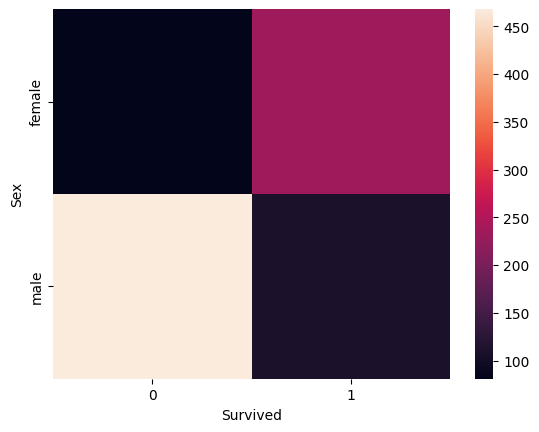

In [35]:
sns.heatmap(pd.crosstab(titanic['Sex'],titanic['Survived']))

<Axes: xlabel='Survived', ylabel='Pclass'>

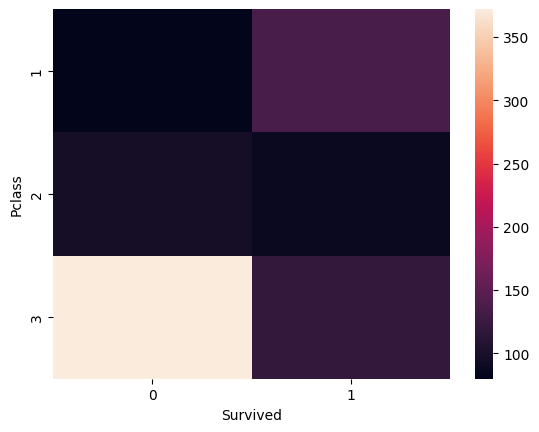

In [37]:
sns.heatmap(pd.crosstab(titanic['Pclass'],titanic['Survived']))

<Axes: xlabel='Pclass'>

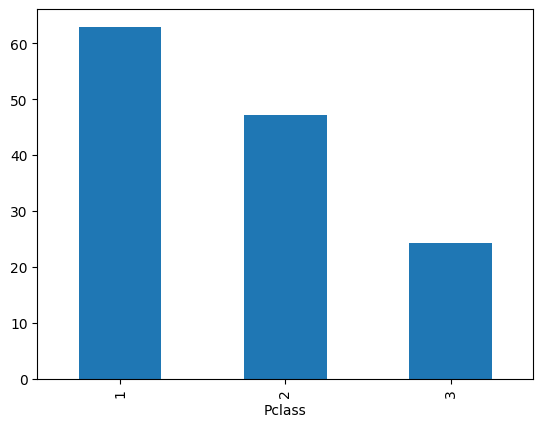

In [42]:
(titanic.groupby('Pclass').mean(numeric_only=True)['Survived']*100).plot(kind='bar')

<Axes: xlabel='Sex'>

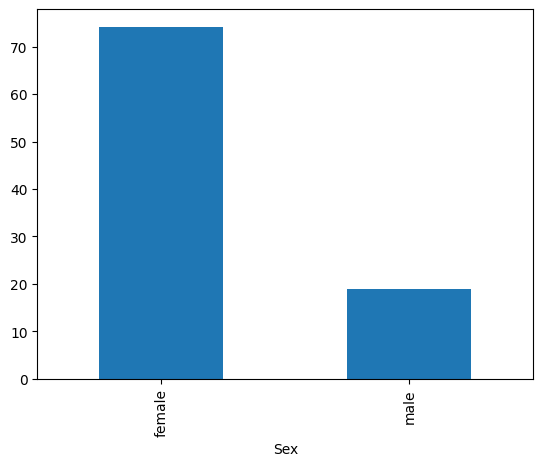

In [43]:
(titanic.groupby('Sex').mean(numeric_only=True)['Survived']*100).plot(kind='bar')

<Axes: xlabel='Embarked'>

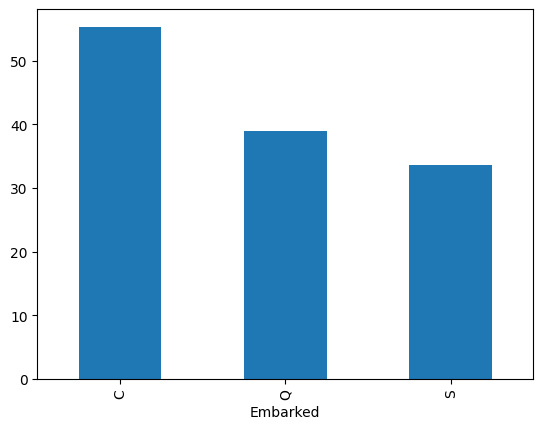

In [44]:
(titanic.groupby('Embarked').mean(numeric_only=True)['Survived']*100).plot(kind='bar')

# 6. ClusterMap (Categorical - Categorical)

In [48]:
pd.crosstab(titanic['SibSp'],titanic['Survived'])

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


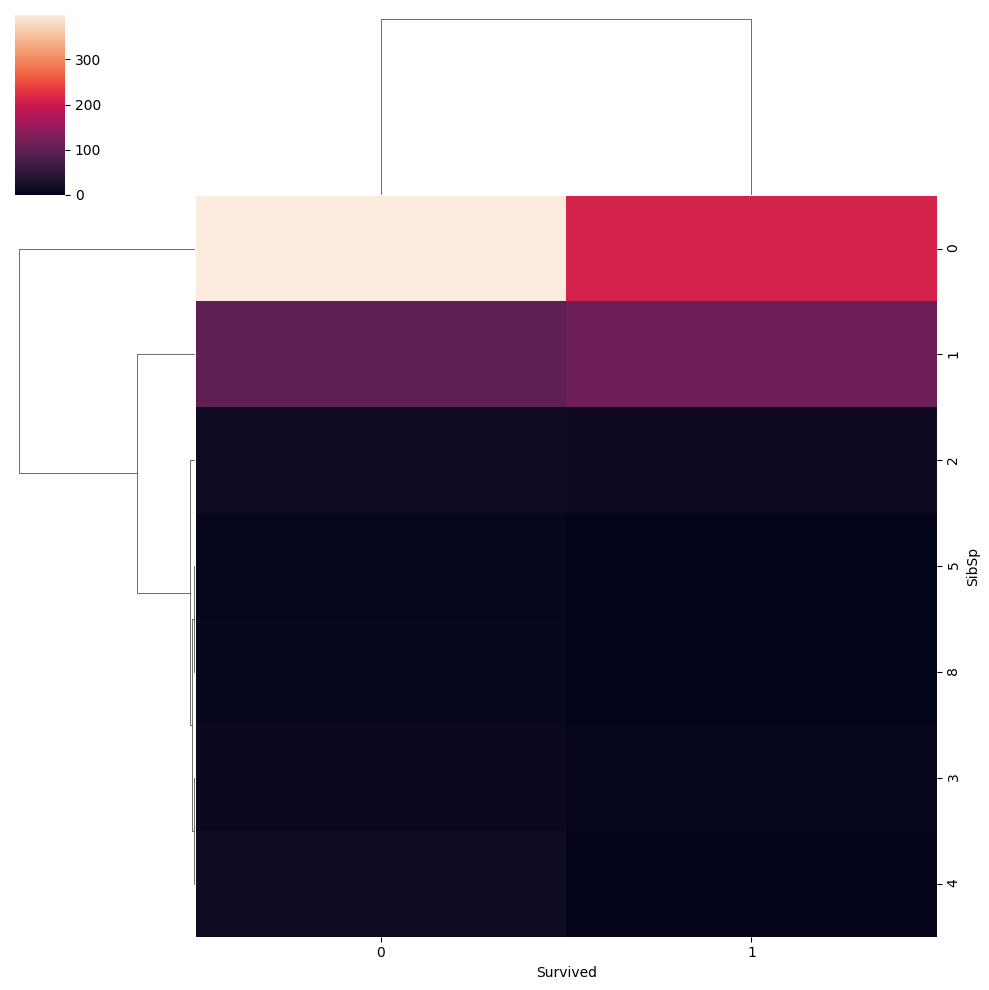

In [49]:
sns.clustermap(pd.crosstab(titanic['SibSp'],titanic['Survived']))

# 7. Pairplot

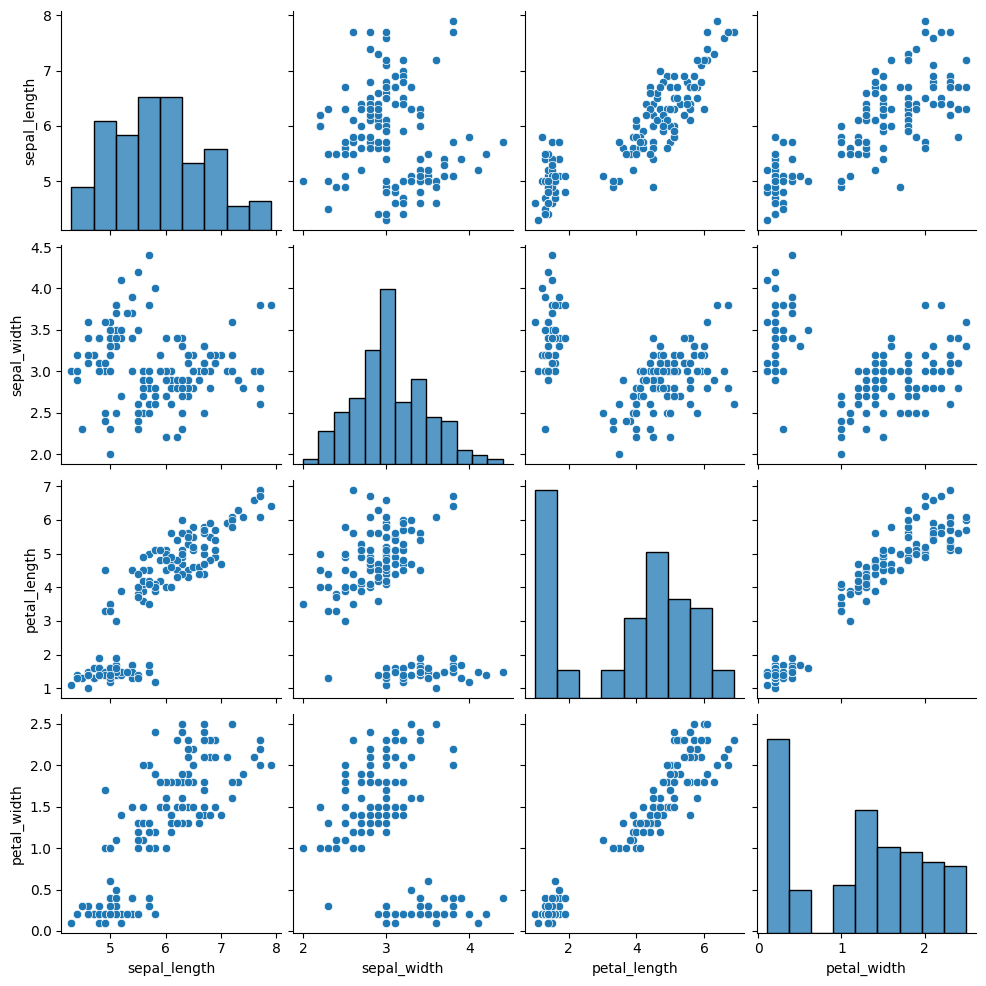

In [50]:
sns.pairplot(iris)

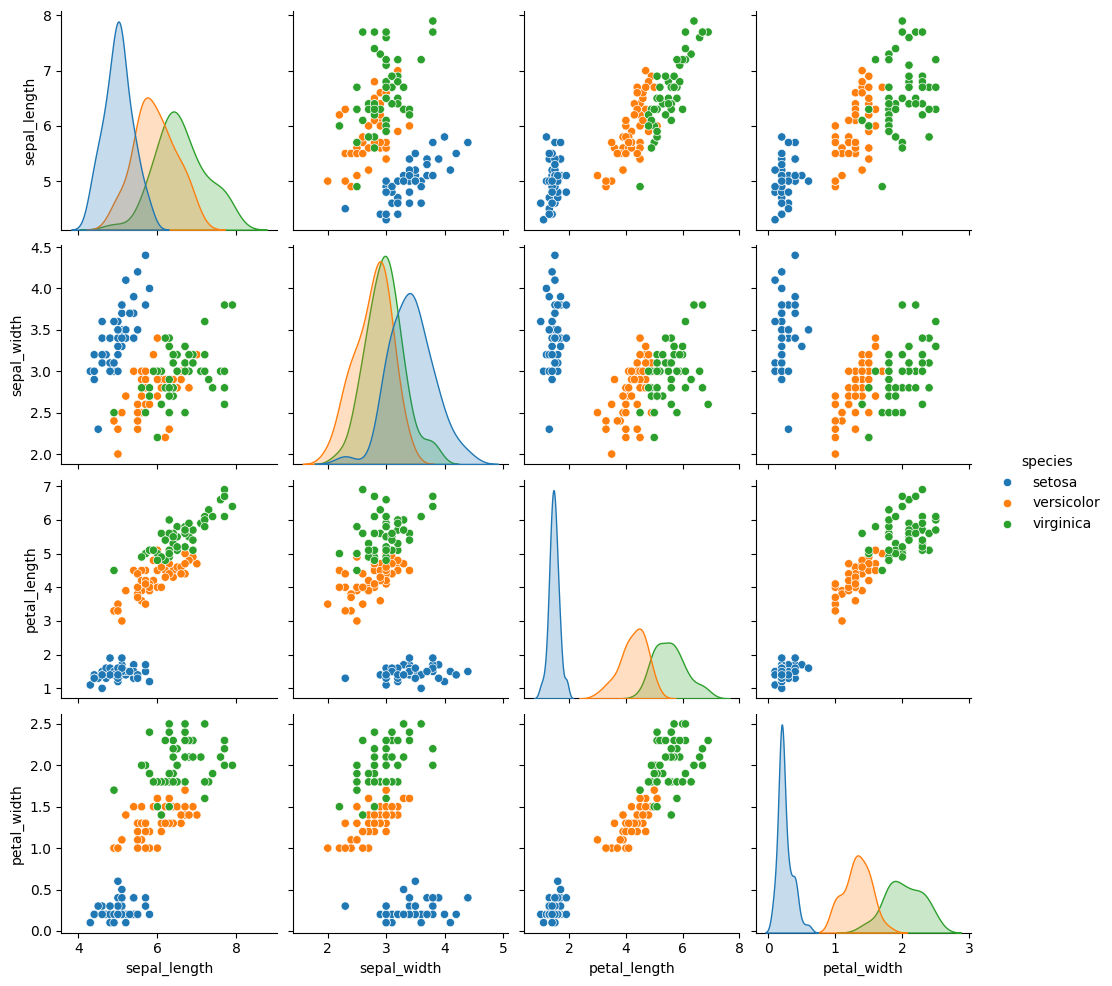

In [51]:
sns.pairplot(iris,hue='species')

# 8. LinePlot (Numerical - Numerical) used when the data varies with time

In [55]:
new = flights.groupby('year').sum(numeric_only=True)

<Axes: xlabel='year', ylabel='passengers'>

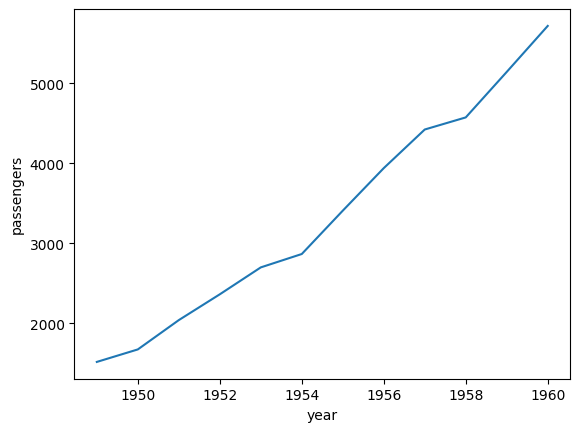

In [58]:
new = new.reset_index()
sns.lineplot(x=new['year'],y=new['passengers'])

In [59]:
flights.pivot_table(values='passengers',index='month',columns='year')

/tmp/ipykernel_244/2056291100.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  flights.pivot_table(values='passengers',index='month',columns='year')


year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


/tmp/ipykernel_244/2230379170.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))


<Axes: xlabel='year', ylabel='month'>

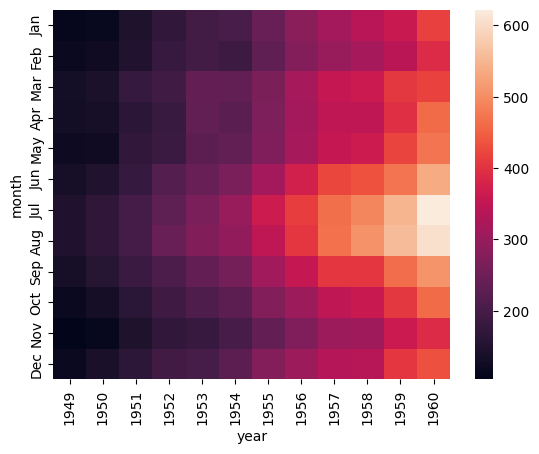

In [60]:
sns.heatmap(flights.pivot_table(values='passengers',index='month',columns='year'))

/tmp/ipykernel_244/1868718285.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))


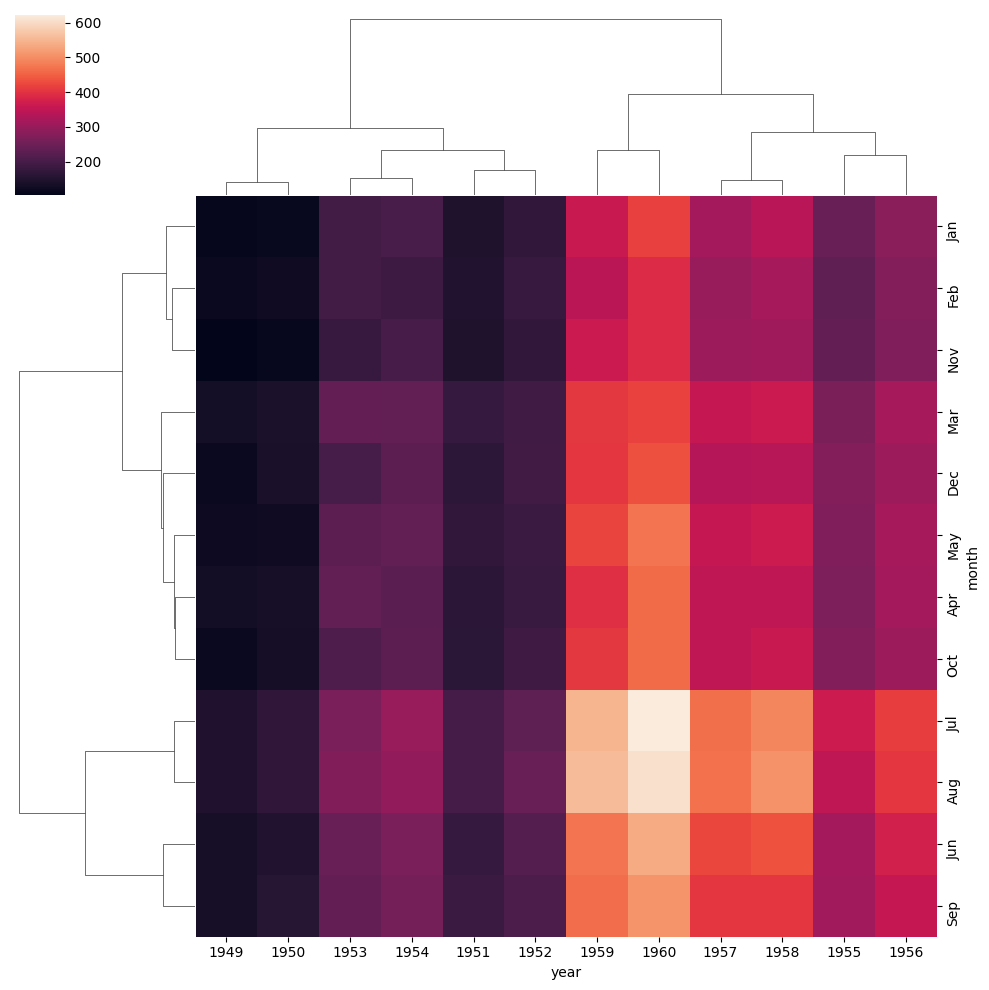

In [62]:
sns.clustermap(flights.pivot_table(values='passengers',index='month',columns='year'))